# House Price Prediction System
# Objective
-> The objective of this project is to predict house prices based on different features such as area, number of bedrooms, bathrooms, neighborhood, and year built using Machine Learning algorithms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df = pd.read_csv("housing_price_dataset.csv")
df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  str    
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), str(1)
memory usage: 2.3 MB


In [3]:
df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [4]:
df.isnull().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

In [5]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [6]:
df = pd.get_dummies(df, columns=["Neighborhood"], drop_first=True)

In [7]:
df.columns


Index(['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Price',
       'Neighborhood_Suburb', 'Neighborhood_Urban'],
      dtype='str')

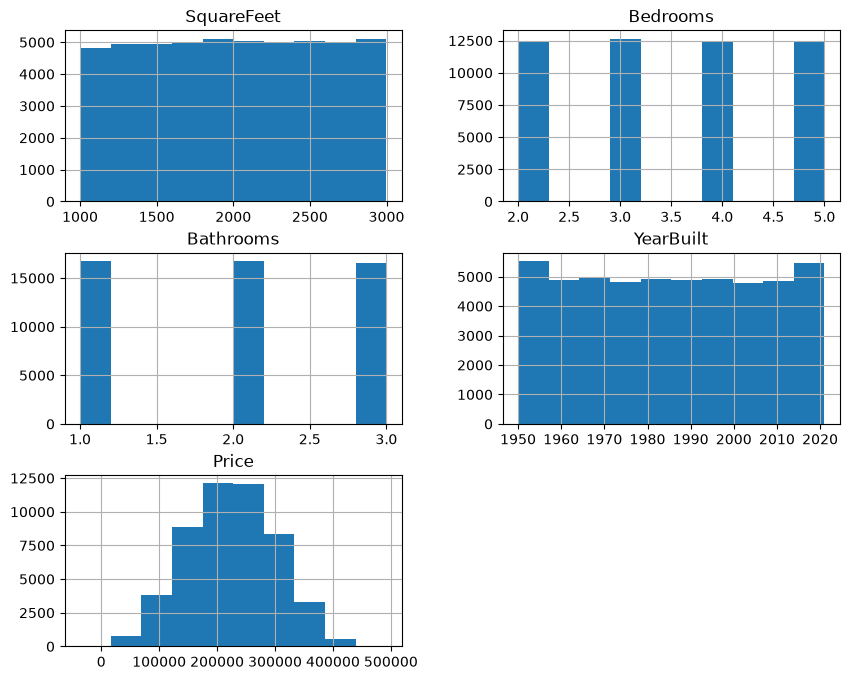

In [8]:
df.hist(figsize=(10,8))
plt.show()

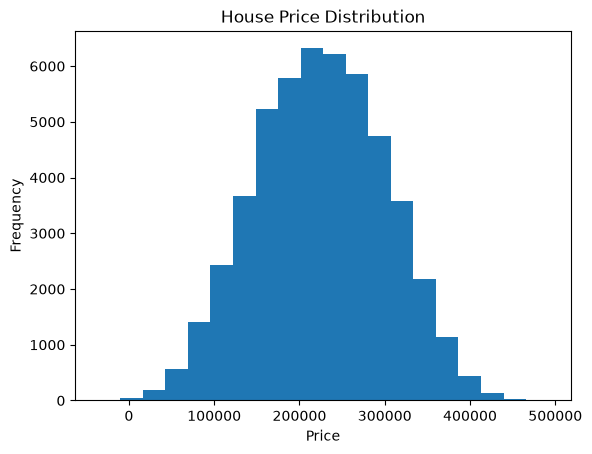

In [9]:
plt.hist(df["Price"],bins=20)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

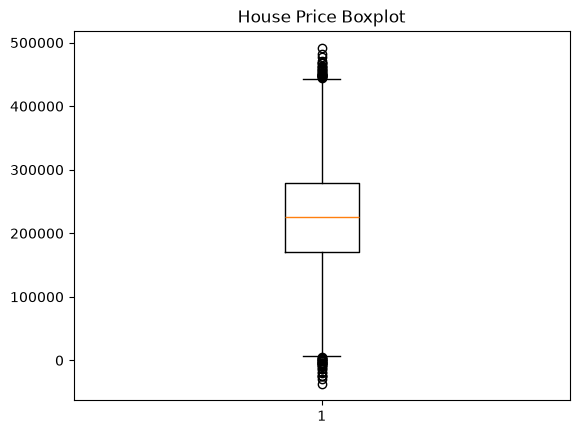

In [10]:
plt.boxplot(df["Price"])
plt.title("House Price Boxplot")
plt.show()

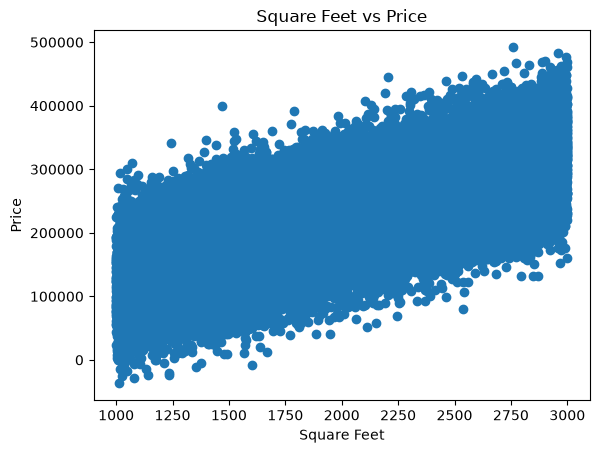

In [11]:
plt.scatter(df["SquareFeet"],df["Price"])
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.title("Square Feet vs Price")
plt.show()

In [12]:
print(df.corr())

                     SquareFeet  Bedrooms  Bathrooms  YearBuilt     Price  \
SquareFeet             1.000000 -0.002638  -0.003275   0.000482  0.750720   
Bedrooms              -0.002638  1.000000   0.007405   0.003147  0.072624   
Bathrooms             -0.003275  0.007405   1.000000   0.003748  0.028418   
YearBuilt              0.000482  0.003147   0.003748   1.000000 -0.002288   
Price                  0.750720  0.072624   0.028418  -0.002288  1.000000   
Neighborhood_Suburb   -0.007665 -0.003029   0.004551   0.003793 -0.014831   
Neighborhood_Urban     0.013528 -0.002127  -0.000883  -0.002051  0.021658   

                     Neighborhood_Suburb  Neighborhood_Urban  
SquareFeet                     -0.007665            0.013528  
Bedrooms                       -0.003029           -0.002127  
Bathrooms                       0.004551           -0.000883  
YearBuilt                       0.003793           -0.002051  
Price                          -0.014831            0.021658  
Neigh

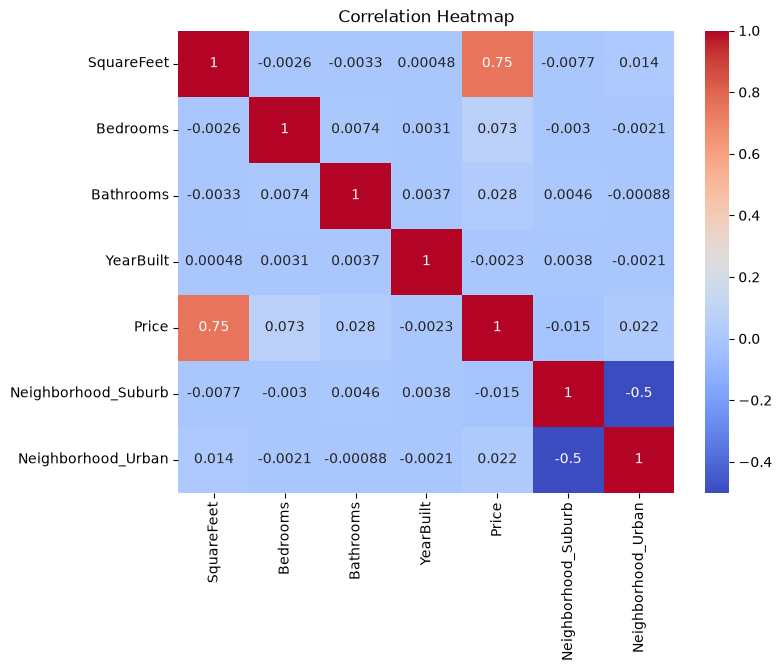

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
X = df.drop("Price", axis=1)
y = df["Price"]


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# Linear Regression Model

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print(" Linear Regression ")
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("MSE:", mean_squared_error(y_test, lr_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

 Linear Regression 
MAE: 39430.16533829791
MSE: 2436249371.3072467
RMSE : 49358.376911191546
R2 Score: 0.5755628630306235


In [17]:
# Decision Tree Regression Model

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print(" Decision Tree Regression ")
print("MAE :", mean_absolute_error(y_test, dt_pred))
print("MSE :", mean_squared_error(y_test, dt_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("R2 Score :", r2_score(y_test, dt_pred))

 Decision Tree Regression 
MAE : 57870.20535287244
MSE : 5259968624.247604
RMSE : 72525.64115020014
R2 Score : 0.08362171388618134


In [18]:
# Random Forest Regression Model

rf_model = RandomForestRegressor(n_estimators=100,random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print(" Random Forest Regression ")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score :", r2_score(y_test, rf_pred))

 Random Forest Regression 
MAE : 41882.26489395157
MSE : 2763556701.0908165
RMSE : 52569.54157200552
R2 Score : 0.5185402168275843


In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ]
})

comparison

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.575563,39430.165338,49358.376911
1,Decision Tree,0.083622,57870.205353,72525.641150
2,Random Forest,0.518540,41882.264894,52569.541572


In [20]:
best_model = comparison.loc[comparison["R2 Score"].idxmax()]

print("Best Model :", best_model["Model"])
print("Best R2 Score :", best_model["R2 Score"])

Best Model : Linear Regression
Best R2 Score : 0.5755628630306235


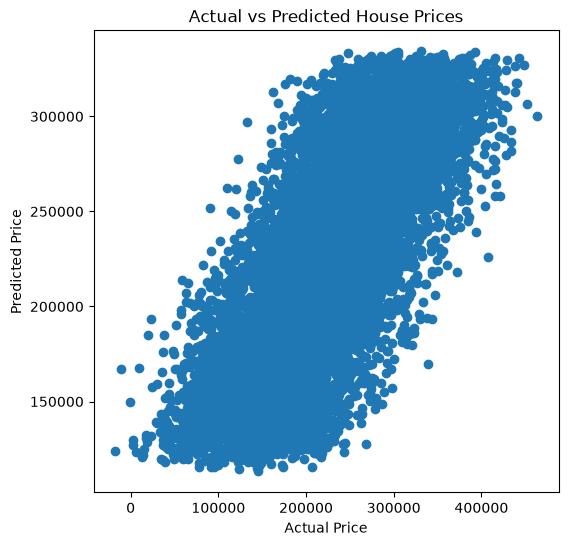

In [21]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

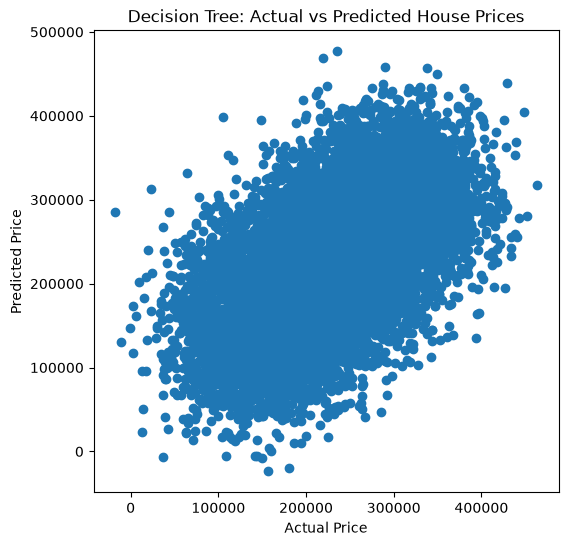

In [24]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, dt_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Decision Tree: Actual vs Predicted House Prices")
plt.show()

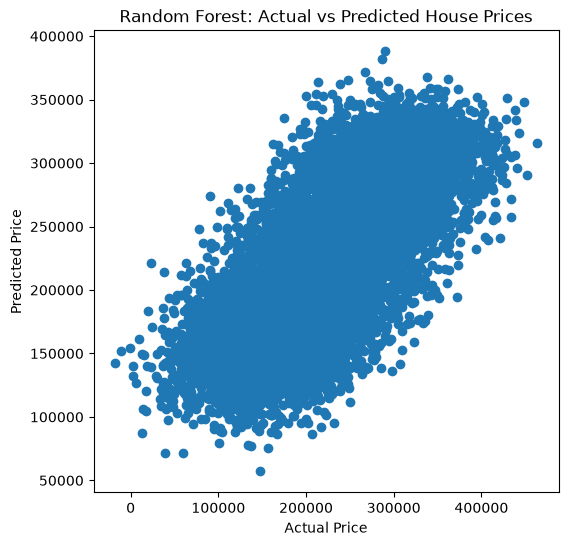

In [25]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Actual vs Predicted House Prices")
plt.show()

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

print(importance.sort_values(by="Importance", ascending=False))

               Feature  Importance
0           SquareFeet    0.742411
3            YearBuilt    0.157073
2            Bathrooms    0.033334
1             Bedrooms    0.029320
4  Neighborhood_Suburb    0.019089
5   Neighborhood_Urban    0.018774


In [24]:
sqft = float(input("Enter Square Feet: "))
bed = int(input("Enter Bedrooms: "))
bath = int(input("Enter Bathrooms: "))
year = int(input("Enter Year Built: "))
neighborhood = input("Enter Neighborhood (Rural/Suburb/Urban): ").strip().lower()
suburb = 1 if neighborhood == "suburb" else 0
urban = 1 if neighborhood == "urban" else 0

new_house = pd.DataFrame({
    "SquareFeet": [sqft],
    "Bedrooms": [bed],
    "Bathrooms": [bath],
    "YearBuilt": [year],
    "Neighborhood_Suburb": [suburb],
    "Neighborhood_Urban": [urban]
})

predicted_price=lr_model.predict(new_house)
print("\nPredicted House Price: ₹", round(predicted_price[0], 2))

Enter Square Feet:  2500
Enter Bedrooms:  4
Enter Bathrooms:  2
Enter Year Built:  2020
Enter Neighborhood (Rural/Suburb/Urban):  Urban



Predicted House Price: ₹ 277429.71


In [25]:
import pickle
with open("house_price_model.pkl", "wb") as file:
    pickle.dump(lr_model, file)
print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

In this project, a House Price Prediction System was developed using Machine Learning. The dataset was first analyzed and preprocessed by checking missing values, duplicate records, and converting categorical data into numerical form. Exploratory Data Analysis (EDA) was also performed to better understand the relationship between different features.

Three regression models were trained and tested:
- Linear Regression
- Decision Tree Regression
- Random Forest Regression

The performance of all three models was compared using MAE, MSE, RMSE, and R² Score. Based on these evaluation metrics, **Linear Regression** gave the best results for this dataset because it achieved the highest R² Score and the lowest prediction error.

Finally, a user input section was added where the user can enter house details such as square feet, bedrooms, bathrooms, year built, and neighborhood to predict the estimated house price. This project helped in understanding the complete Machine Learning workflow, from data preprocessing to model evaluation and prediction.